In [510]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/johnsmith88/heart-disease-dataset/heart.csv


In [511]:
df = pd.read_csv("/kaggle/input/datasets/johnsmith88/heart-disease-dataset/heart.csv")

In [512]:
df['target'].value_counts()

target
1    526
0    499
Name: count, dtype: int64

In [513]:
df.shape

(1025, 14)

In [514]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [515]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [516]:
import matplotlib.pyplot as mp
import seaborn as ss

In [517]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [518]:
numerical_col = df.iloc[:,[0,3,4,7,9]]
cat_col = df.iloc[:,[1,2,5,6,8,10,11,12]]

In [519]:
df.shape

(1025, 14)

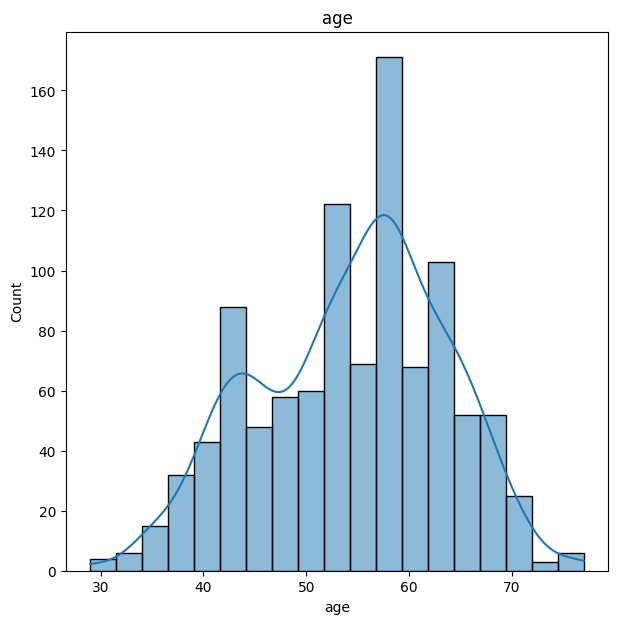

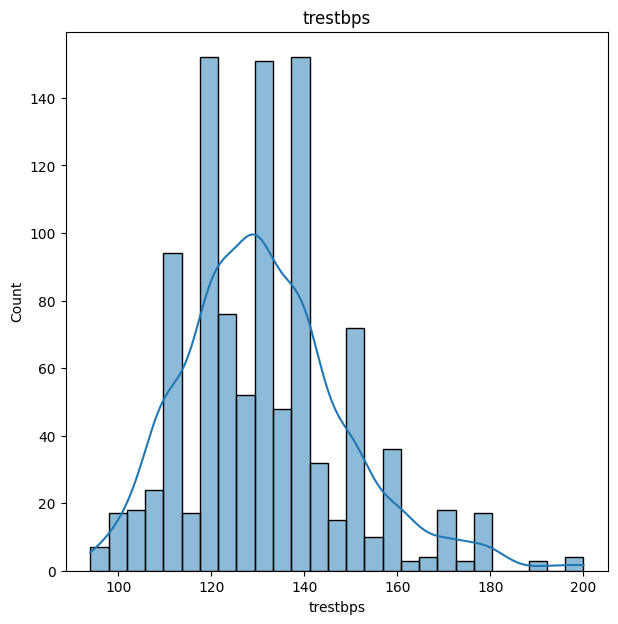

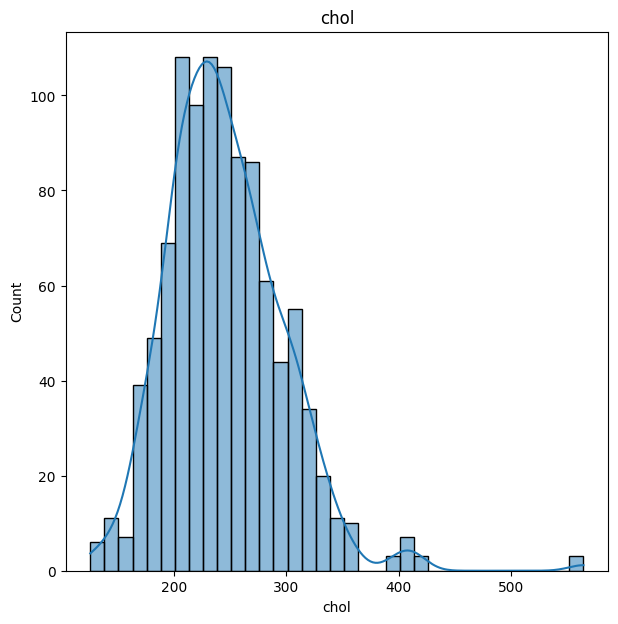

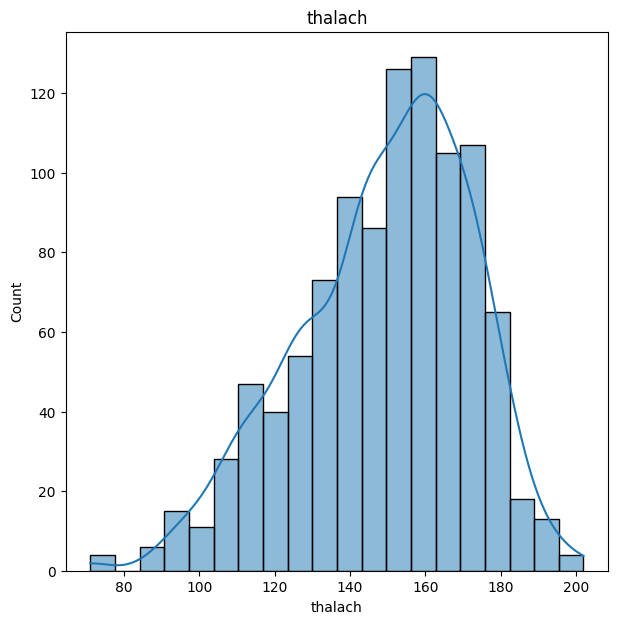

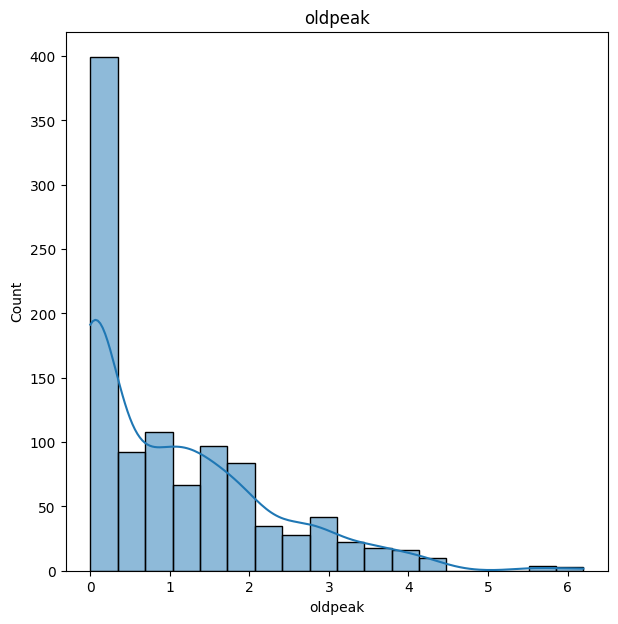

In [520]:
for i in numerical_col.columns : 
    mp.figure(figsize=(7,7))
    ss.histplot(numerical_col[i],kde=True)
    mp.title(i)

In [521]:
numerical_col['target']= df['target']

/tmp/ipykernel_58/734816182.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  numerical_col['target']= df['target']


In [522]:
num_col = numerical_col.columns

In [523]:
new_col = num_col.tolist()

In [524]:
numerical_col

,age,trestbps,chol,thalach,oldpeak,target
0,52,125,212,168,1.0,0
1,53,140,203,155,3.1,0
2,70,145,174,125,2.6,0
3,61,148,203,161,0.0,0
4,62,138,294,106,1.9,0
...,...,...,...,...,...,...
1020,59,140,221,164,0.0,1
1021,60,125,258,141,2.8,0
1022,47,110,275,118,1.0,0
1023,50,110,254,159,0.0,1


In [525]:
from sklearn.preprocessing import StandardScaler
std = StandardScaler()
numerical_col=numerical_col.drop(columns=['target'],axis=1)
numerical_col_trans=std.fit_transform(numerical_col)

In [526]:
numerical_df = pd.DataFrame(numerical_col_trans,columns=numerical_col.columns)

In [527]:
df['chol'].describe()

count    1025.00000
mean      246.00000
std        51.59251
min       126.00000
25%       211.00000
50%       240.00000
75%       275.00000
max       564.00000
Name: chol, dtype: float64

In [528]:
q1 = numerical_df['trestbps'].quantile(0.25)
q3 = numerical_df['trestbps'].quantile(0.75)
iqr = q3-q1
lower_bound=q1 - 1.5*q3
upper_bound = q3 + 1.5*iqr


In [529]:
q1_chol = numerical_df['chol'].quantile(0.25)
q3_chol = numerical_df['chol'].quantile(0.75)
iqr_chol = q3_chol-q1_chol
lower_bound2=q1_chol - 1.5*q3_chol
upper_bound2 = q3_chol + 1.5*iqr_chol


In [530]:
numerical_df['chol'] = np.where(numerical_df['chol']<lower_bound2,lower_bound2,numerical_df['chol'])
numerical_df['chol'] = np.where(numerical_df['chol']>upper_bound2,upper_bound2,numerical_df['chol'])


<Axes: >

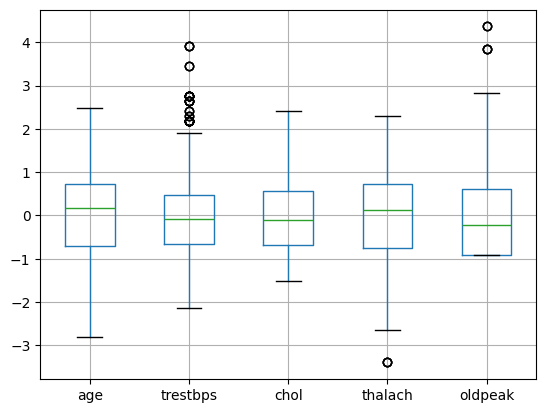

In [531]:
numerical_df.boxplot()

In [532]:
numerical_df['trestbps'] = np.where(numerical_df['trestbps']<lower_bound,lower_bound,numerical_df['trestbps'])
numerical_df['trestbps'] = np.where(numerical_df['trestbps']>upper_bound,upper_bound,numerical_df['trestbps'])


In [533]:
numerical_df['target'] = df['target']

<Axes: >

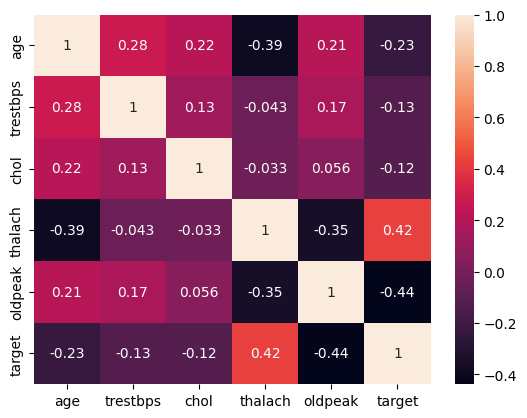

In [534]:
ss.heatmap(numerical_df.corr(),annot=True)

In [535]:
from sklearn.model_selection import train_test_split

In [536]:
all_cols =  cat_col.columns.tolist() + new_col

In [537]:
df_new= np.hstack((cat_col,numerical_df))

In [538]:
df2 = pd.DataFrame(df_new,columns=all_cols)

In [539]:
df2.head()

,sex,cp,fbs,restecg,exang,slope,ca,thal,age,trestbps,chol,thalach,oldpeak,target
0,1.0,0.0,0.0,1.0,0.0,2.0,2.0,3.0,-0.268437,-0.377636,-0.659332,0.821321,-0.060888,0.0
1,1.0,0.0,1.0,0.0,1.0,0.0,0.0,3.0,-0.158157,0.479107,-0.833861,0.255968,1.727137,0.0
2,1.0,0.0,0.0,1.0,1.0,0.0,0.0,3.0,1.716595,0.764688,-1.396233,-1.048692,1.301417,0.0
3,1.0,0.0,0.0,1.0,0.0,2.0,1.0,3.0,0.724079,0.936037,-0.833861,0.516900,-0.912329,0.0
4,0.0,0.0,1.0,1.0,0.0,1.0,3.0,2.0,0.834359,0.364875,0.930822,-1.874977,0.705408,0.0


In [540]:
x = df2.iloc[:,0:13]
y = df2.iloc[:,-1]

In [541]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [542]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [543]:
svc = SVC()
svc.fit(x_train,y_train)

SVC()

In [544]:
log = LogisticRegression()
log.fit(x_train,y_train)

LogisticRegression()

In [545]:
knn  =KNeighborsClassifier()
knn.fit(x_train,y_train)

KNeighborsClassifier()

In [546]:
from sklearn.metrics import accuracy_score

In [547]:
pred = log.predict(x_test)

In [548]:
accuracy_score(y_test,pred)

0.8682926829268293

In [549]:
accuracy_score(y_test,knn.predict(x_test))

0.8878048780487805

In [550]:
accuracy_score(y_test,svc.predict(x_test))

0.926829268292683